In [1]:
# =============================================================================
# FEATURE VISUALIZATION & IMPORTANCE ANALYSIS
# =============================================================================
"""
Bu bölümde:
1. Feature'ların churn ile correlation'ını görselleştireceğiz
2. Random Forest ile feature importance bulacağız
3. Correlation heatmap oluşturacağız
4. Feature distribution'ları analiz edeceğiz
"""


"\nBu bölümde:\n1. Feature'ların churn ile correlation'ını görselleştireceğiz\n2. Random Forest ile feature importance bulacağız\n3. Correlation heatmap oluşturacağız\n4. Feature distribution'ları analiz edeceğiz\n"

In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# Görselleştirme ayarları
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

print("="*80)
print("FEATURE VISUALIZATION & IMPORTANCE ANALYSIS")
print("="*80)


FEATURE VISUALIZATION & IMPORTANCE ANALYSIS


In [4]:

# =============================================================================
# 1. VERİ YÜKLEME VE HAZIRLIK
# =============================================================================
"""
Temizlenmiş feature'ları yükleyip modeling için hazırlayacağız.
"""

print("\n1. Loading processed data...")

# Veriyi yükle
data_path = '../data/processed/'
df = pd.read_csv(data_path + 'customer_features_final_clean.csv')

print(f"   ✓ Loaded data: {df.shape}")
print(f"   ✓ Churn rate: {df['is_churned'].mean()*100:.2f}%")

# Duplicate kolonları temizle (eğer varsa)
duplicate_cols = [col for col in df.columns if col.endswith('_x') or col.endswith('_y')]
if len(duplicate_cols) > 0:
    print(f"\n   Cleaning {len(duplicate_cols)} duplicate columns...")
    
    # top_category
    if 'top_category_x' in df.columns and 'top_category_y' in df.columns:
        df['top_category'] = df['top_category_y'].fillna(df['top_category_x'])
        df.drop(['top_category_x', 'top_category_y'], axis=1, inplace=True)
    
    # preferred_time_of_day
    if 'preferred_time_of_day_x' in df.columns and 'preferred_time_of_day_y' in df.columns:
        df['preferred_time_of_day'] = df['preferred_time_of_day_y'].fillna(df['preferred_time_of_day_x'])
        df.drop(['preferred_time_of_day_x', 'preferred_time_of_day_y'], axis=1, inplace=True)
    
    print(f"   ✓ Cleaned duplicates. New shape: {df.shape}")


1. Loading processed data...
   ✓ Loaded data: (96478, 62)
   ✓ Churn rate: 59.82%

   Cleaning 10 duplicate columns...
   ✓ Cleaned duplicates. New shape: (96478, 62)


In [5]:
# =============================================================================
# 2. FEATURE'LARI HAZIRLA
# =============================================================================
"""
Modeling için sadece numeric ve boolean feature'ları kullanacağız.
Categorical feature'lar zaten one-hot encoded.
"""

print("\n2. Preparing features for analysis...")

# Modeling için hariç tutulacak kolonlar
exclude_cols = [
    'customer_id',           # identifier
    'is_churned',           # target
    'first_order',          # datetime (zaten recency'de var)
    'last_order',           # datetime (zaten recency'de var)
    'preferred_payment_type', # categorical (zaten one-hot encoded)
    'segment',              # categorical (zaten one-hot encoded)
    'top_category',         # categorical (kullanmayacağız - çok fazla unique value)
    'preferred_time_of_day', # categorical (zaten one-hot encoded)
    'r_score', 'f_score', 'm_score'  # categorical (zaten recency, frequency, monetary var)
]

# Feature listesi oluştur
feature_cols = [col for col in df.columns if col not in exclude_cols]

print(f"   ✓ Total features for modeling: {len(feature_cols)}")
print(f"   ✓ Excluded columns: {len(exclude_cols)}")

# X ve y oluştur
X = df[feature_cols].copy()
y = df['is_churned'].copy()

# Boolean kolonları int'e çevir (model için)
bool_cols = X.select_dtypes(include=['bool']).columns
X[bool_cols] = X[bool_cols].astype(int)

print(f"\n   Feature breakdown:")
print(f"   - Numeric features: {len(X.select_dtypes(include=[np.number]).columns)}")
print(f"   - Total features: {X.shape[1]}")



2. Preparing features for analysis...
   ✓ Total features for modeling: 51
   ✓ Excluded columns: 11

   Feature breakdown:
   - Numeric features: 51
   - Total features: 51



3. Computing correlations with target variable...

   Top 10 Correlated Features:
                        feature  correlation
0                       recency     0.791904
26  segment_Potential Loyalists    -0.536010
21            segment_Champions    -0.531702
20              segment_At Risk     0.358445
24       segment_Need Attention     0.242279
25               segment_Others     0.241599
27            segment_Promising     0.241037
22                 segment_Lost     0.239482
18            avg_delivery_time     0.140778
19            max_delivery_time     0.140778


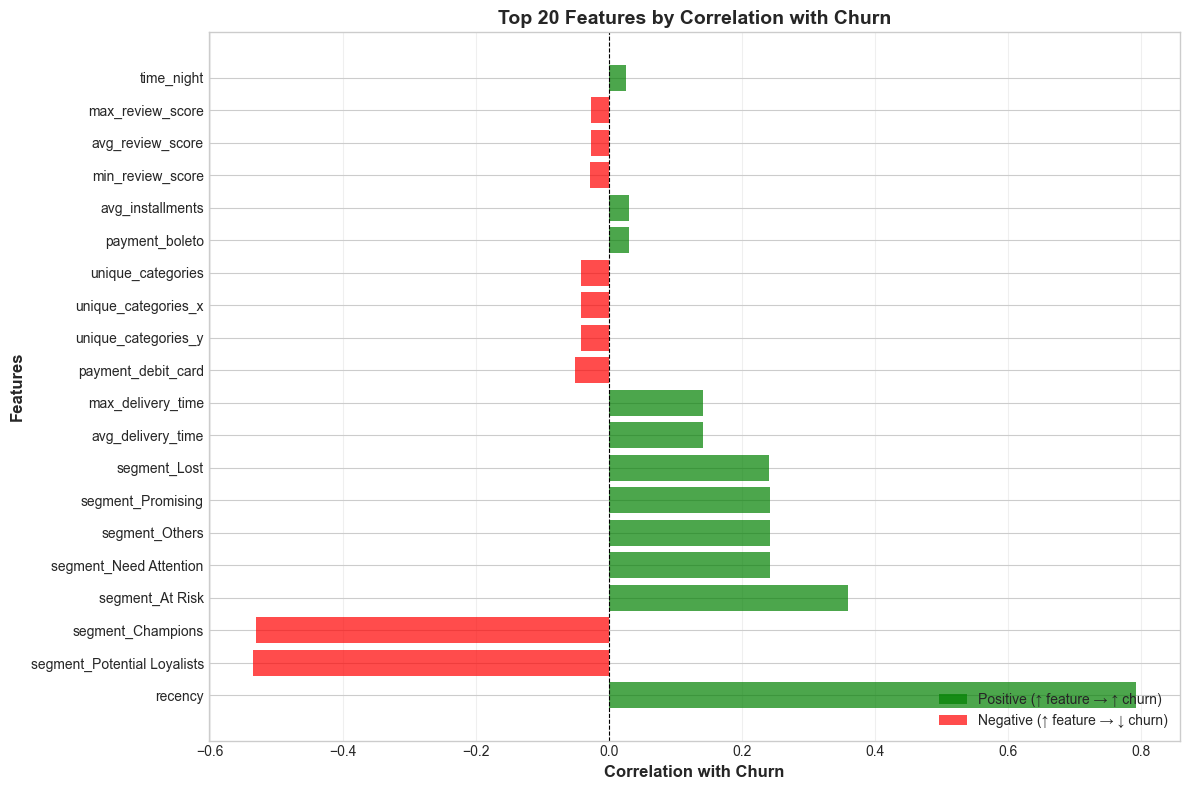


   ✓ Correlation plot saved!


In [6]:
# =============================================================================
# 3. CORRELATION ANALYSIS WITH TARGET
# =============================================================================
"""
Her feature'ın churn ile correlation'ını hesaplayıp görselleştireceğiz.
Bu bize hangi feature'ların en predictive olduğunu gösterir.
"""

print("\n3. Computing correlations with target variable...")

# Correlation'ları hesapla
correlations = pd.DataFrame({
    'feature': X.columns,
    'correlation': [X[col].corr(y) for col in X.columns]
})

# Absolute değere göre sırala (pozitif ve negatif correlation'lar eşit önemli)
correlations['abs_correlation'] = correlations['correlation'].abs()
correlations = correlations.sort_values('abs_correlation', ascending=False)

print(f"\n   Top 10 Correlated Features:")
print(correlations.head(10)[['feature', 'correlation']])

# Görselleştirme: Top 20 Feature Correlation
plt.figure(figsize=(12, 8))
top_n = 20
top_features = correlations.head(top_n)

# Horizontal bar plot
colors = ['red' if x < 0 else 'green' for x in top_features['correlation']]
plt.barh(range(len(top_features)), top_features['correlation'], color=colors, alpha=0.7)
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Correlation with Churn', fontsize=12, fontweight='bold')
plt.ylabel('Features', fontsize=12, fontweight='bold')
plt.title(f'Top {top_n} Features by Correlation with Churn', fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.grid(axis='x', alpha=0.3)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='green', alpha=0.7, label='Positive (↑ feature → ↑ churn)'),
    Patch(facecolor='red', alpha=0.7, label='Negative (↑ feature → ↓ churn)')
]
plt.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.savefig('../data/processed/feature_correlation.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n   ✓ Correlation plot saved!")



4. Computing Random Forest feature importance...
   ✓ Train set: (67534, 51), Test set: (28944, 51)
   Training Random Forest for feature importance...

   Top 10 Important Features (Random Forest):
                        feature  importance
0                       recency    0.569975
21            segment_Champions    0.120292
26  segment_Potential Loyalists    0.110171
20              segment_At Risk    0.063829
24       segment_Need Attention    0.029820
25               segment_Others    0.026778
27            segment_Promising    0.025515
22                 segment_Lost    0.025425
23      segment_Loyal Customers    0.010776
18            avg_delivery_time    0.007441

   Model Performance (preliminary):
   - Train Accuracy: 1.0000
   - Test Accuracy: 1.0000


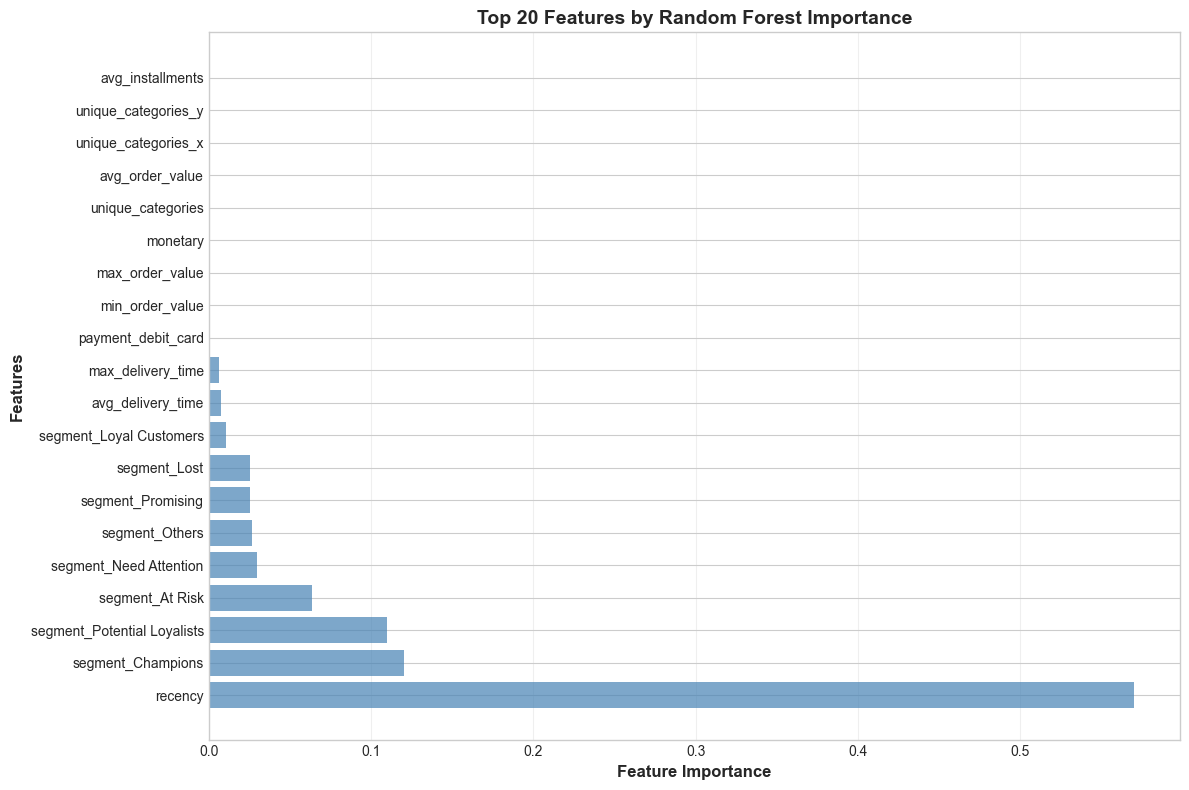


   ✓ Feature importance plot saved!


In [7]:

# =============================================================================
# 4. RANDOM FOREST FEATURE IMPORTANCE
# =============================================================================
"""
Random Forest modelini kullanarak feature importance'ları hesaplayacağız.
Bu, correlation'dan daha güçlü çünkü non-linear relationships'i yakalar.
"""

print("\n4. Computing Random Forest feature importance...")

# Train-test split (sadece importance için, final model değil)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"   ✓ Train set: {X_train.shape}, Test set: {X_test.shape}")

# Random Forest model (hızlı importance için, hyperparameter tuning yok)
rf_model = RandomForestClassifier(
    n_estimators=100,        # 100 ağaç yeterli
    max_depth=10,            # Overfitting önlemek için
    min_samples_split=50,    # Her split için minimum sample
    min_samples_leaf=20,     # Her leaf'te minimum sample
    random_state=42,
    n_jobs=-1,              # Tüm CPU core'ları kullan
    class_weight='balanced'  # Class imbalance için
)

print("   Training Random Forest for feature importance...")
rf_model.fit(X_train, y_train)

# Feature importance'ları al
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print(f"\n   Top 10 Important Features (Random Forest):")
print(feature_importance.head(10))

# Training accuracy (sadece bilgi için)
train_score = rf_model.score(X_train, y_train)
test_score = rf_model.score(X_test, y_test)
print(f"\n   Model Performance (preliminary):")
print(f"   - Train Accuracy: {train_score:.4f}")
print(f"   - Test Accuracy: {test_score:.4f}")

# Görselleştirme: Top 20 Feature Importance
plt.figure(figsize=(12, 8))
top_n = 20
top_important = feature_importance.head(top_n)

plt.barh(range(len(top_important)), top_important['importance'], color='steelblue', alpha=0.7)
plt.yticks(range(len(top_important)), top_important['feature'])
plt.xlabel('Feature Importance', fontsize=12, fontweight='bold')
plt.ylabel('Features', fontsize=12, fontweight='bold')
plt.title(f'Top {top_n} Features by Random Forest Importance', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('../data/processed/feature_importance_rf.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n   ✓ Feature importance plot saved!")



5. Creating correlation heatmap for top features...
   Selected 11 top features for heatmap


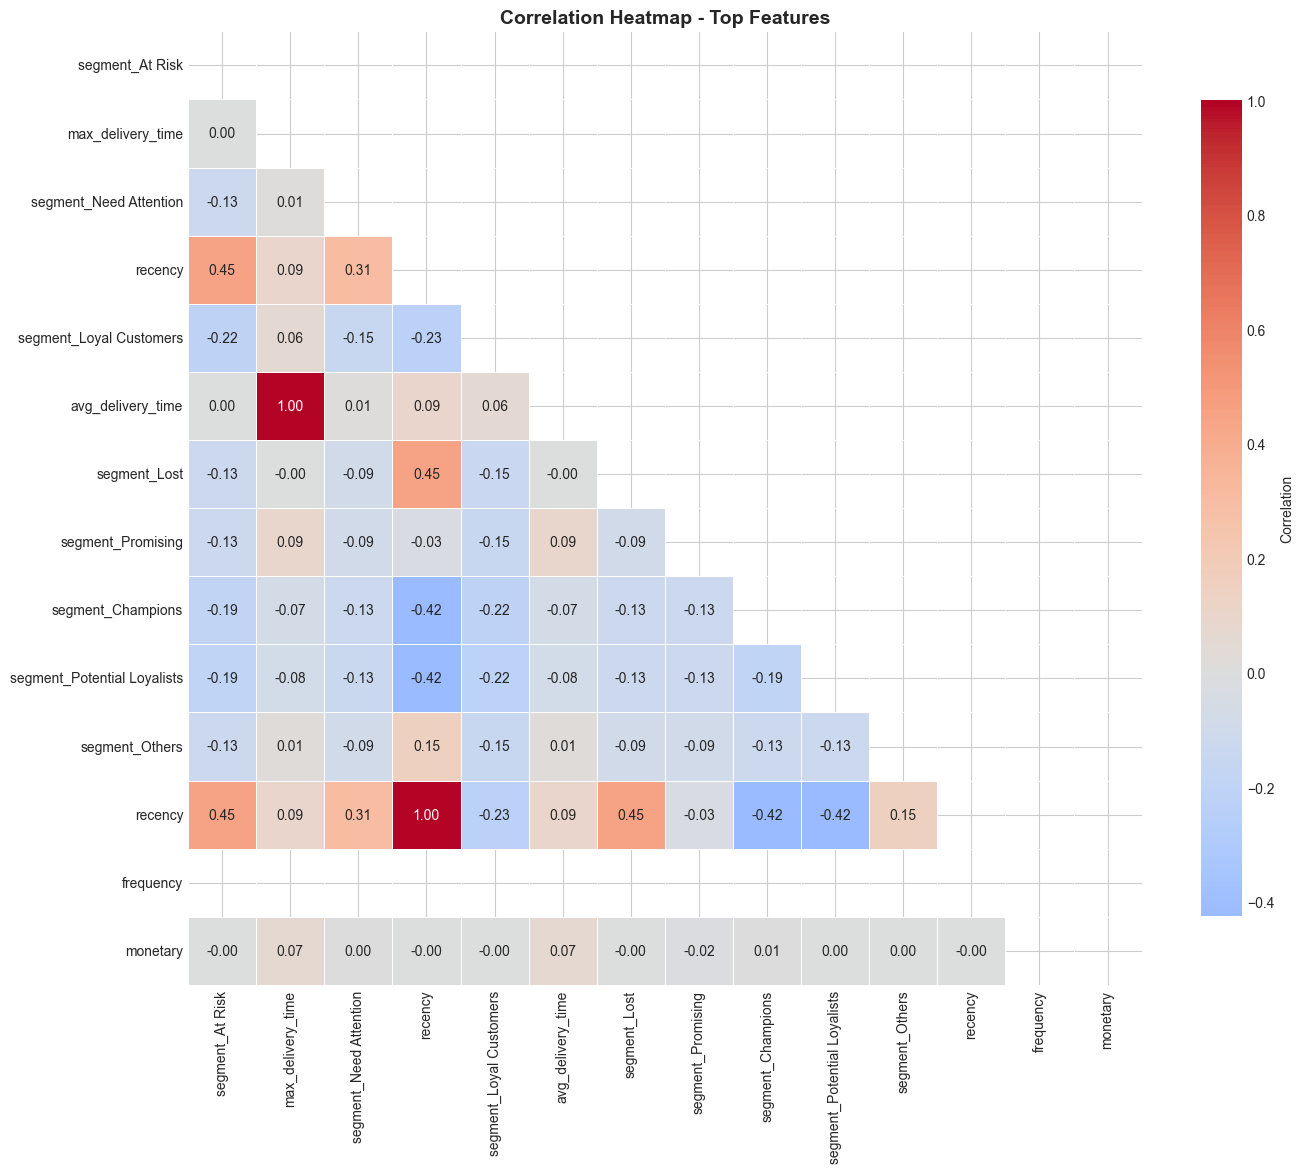


   ✓ Correlation heatmap saved!

   ⚠️  Found 2 highly correlated feature pairs (>0.8):
      max_delivery_time <-> avg_delivery_time: 1.000
      recency <-> recency: 1.000


In [8]:
# =============================================================================
# 5. CORRELATION HEATMAP (TOP FEATURES)
# =============================================================================
"""
En önemli feature'lar arasındaki correlation'ları görselleştireceğiz.
Yüksek correlation'lu feature'lar redundant olabilir (feature selection için önemli).
"""

print("\n5. Creating correlation heatmap for top features...")

# Top 15 feature'ı seç (hem correlation hem importance'a göre)
top_corr_features = correlations.head(10)['feature'].tolist()
top_imp_features = feature_importance.head(10)['feature'].tolist()

# İkisini birleştir ve unique yap
top_combined = list(set(top_corr_features + top_imp_features))[:15]

print(f"   Selected {len(top_combined)} top features for heatmap")

# Correlation matrix
corr_matrix = X[top_combined + ['recency', 'frequency', 'monetary']].corr()

# Heatmap
plt.figure(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Üst üçgeni maskele

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,           # Değerleri göster
    fmt='.2f',            # 2 decimal
    cmap='coolwarm',      # Renk paleti
    center=0,             # 0 merkez
    square=True,          # Kare hücreler
    linewidths=0.5,       # Hücre sınırları
    cbar_kws={"shrink": 0.8, "label": "Correlation"}
)

plt.title('Correlation Heatmap - Top Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n   ✓ Correlation heatmap saved!")

# High correlation pairs (potential redundancy)
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.8:  # 0.8'den yüksek correlation
            high_corr_pairs.append({
                'feature_1': corr_matrix.columns[i],
                'feature_2': corr_matrix.columns[j],
                'correlation': corr_matrix.iloc[i, j]
            })

if len(high_corr_pairs) > 0:
    print(f"\n   ⚠️  Found {len(high_corr_pairs)} highly correlated feature pairs (>0.8):")
    for pair in high_corr_pairs:
        print(f"      {pair['feature_1']} <-> {pair['feature_2']}: {pair['correlation']:.3f}")
else:
    print(f"\n   ✅ No highly correlated feature pairs found (all <0.8)")


6. Creating feature distribution plots...


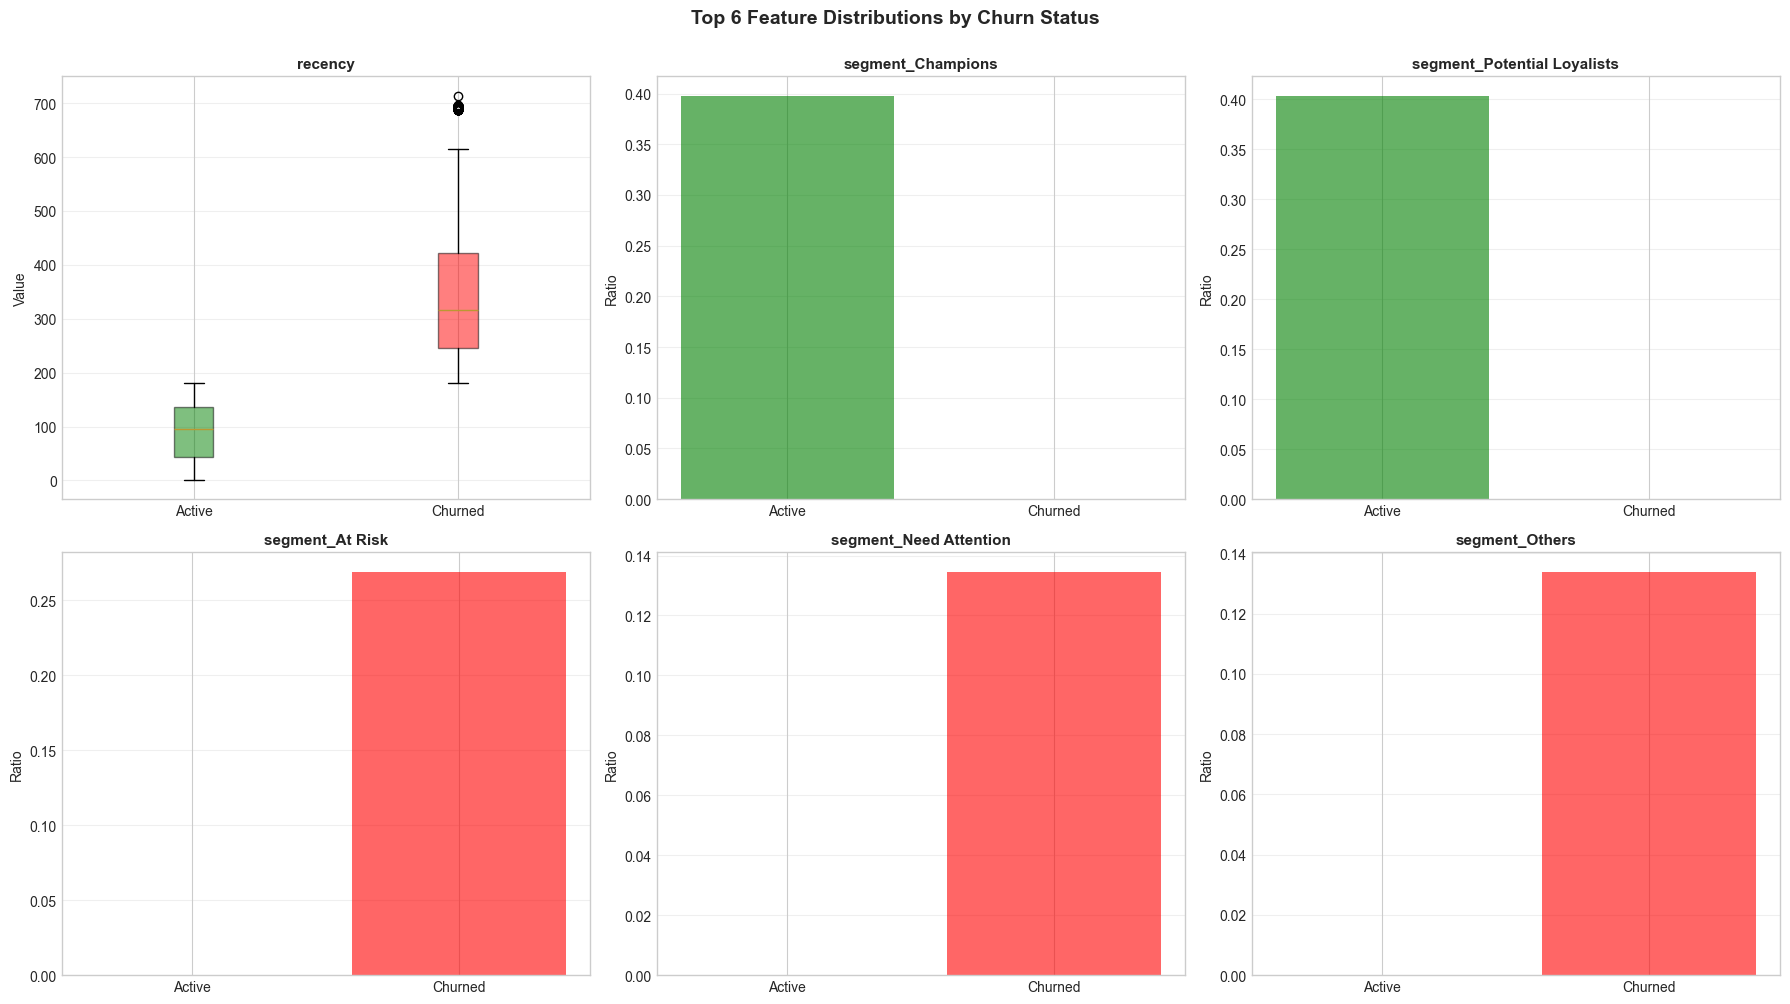


   ✓ Distribution plots saved!


In [9]:
# =============================================================================
# 6. FEATURE DISTRIBUTION BY CHURN STATUS
# =============================================================================
"""
En önemli feature'ların churn durumuna göre nasıl dağıldığını görelim.
Bu, feature'ların discriminative power'ını gösterir.
"""

print("\n6. Creating feature distribution plots...")

# Top 6 feature'ı seç
top_6_features = feature_importance.head(6)['feature'].tolist()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for idx, feature in enumerate(top_6_features):
    ax = axes[idx]
    
    # Churn durumuna göre ayır
    churned = df[df['is_churned'] == 1][feature]
    active = df[df['is_churned'] == 0][feature]
    
    # Box plot veya histogram (feature tipine göre)
    if df[feature].nunique() > 10:  # Continuous feature
        # Box plot
        data_to_plot = [active, churned]
        bp = ax.boxplot(data_to_plot, labels=['Active', 'Churned'], patch_artist=True)
        
        # Renklendirme
        bp['boxes'][0].set_facecolor('green')
        bp['boxes'][0].set_alpha(0.5)
        bp['boxes'][1].set_facecolor('red')
        bp['boxes'][1].set_alpha(0.5)
        
        ax.set_ylabel('Value')
    else:  # Binary feature
        # Bar plot
        active_mean = active.mean()
        churned_mean = churned.mean()
        
        ax.bar(['Active', 'Churned'], [active_mean, churned_mean], 
               color=['green', 'red'], alpha=0.6)
        ax.set_ylabel('Ratio')
    
    ax.set_title(f'{feature}', fontsize=11, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Top 6 Feature Distributions by Churn Status', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('../data/processed/feature_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n   ✓ Distribution plots saved!")

In [10]:

# =============================================================================
# 7. SUMMARY REPORT
# =============================================================================

print("\n" + "="*80)
print("VISUALIZATION SUMMARY")
print("="*80)

print(f"\n📊 Created Visualizations:")
print(f"   1. feature_correlation.png - Top 20 correlation with churn")
print(f"   2. feature_importance_rf.png - Top 20 Random Forest importance")
print(f"   3. correlation_heatmap.png - Feature intercorrelations")
print(f"   4. feature_distributions.png - Top 6 feature distributions")

print(f"\n🎯 Key Insights:")
print(f"   - Most predictive feature: {feature_importance.iloc[0]['feature']}")
print(f"   - Highest correlation: {correlations.iloc[0]['feature']} ({correlations.iloc[0]['correlation']:.3f})")
print(f"   - Highly correlated pairs: {len(high_corr_pairs)}")

print(f"\n💾 All plots saved to: {data_path}")
print(f"\n✅ Visualization complete! Ready for feature selection.")


VISUALIZATION SUMMARY

📊 Created Visualizations:
   1. feature_correlation.png - Top 20 correlation with churn
   2. feature_importance_rf.png - Top 20 Random Forest importance
   3. correlation_heatmap.png - Feature intercorrelations
   4. feature_distributions.png - Top 6 feature distributions

🎯 Key Insights:
   - Most predictive feature: recency
   - Highest correlation: recency (0.792)
   - Highly correlated pairs: 2

💾 All plots saved to: ../data/processed/

✅ Visualization complete! Ready for feature selection.


## feature selection

In [11]:
# =============================================================================
# INTELLIGENT FEATURE SELECTION
# =============================================================================
"""
Feature selection stratejileri:
1. Correlation-based removal (redundant features)
2. Importance-based selection (low importance features)
3. Variance threshold (low variance features)
4. Business logic (domain knowledge)

Hedef: 55 feature'dan ~30-35'e düşürmek
"""

import pandas as pd
import numpy as np
from sklearn.feature_selection import VarianceThreshold
import json

print("="*80)
print("INTELLIGENT FEATURE SELECTION")
print("="*80)

# Önceki adımdan devam ediyoruz (X, y, correlations, feature_importance mevcut)
# Eğer yeni bir notebook'ta çalışıyorsanız, önce veriyi yükleyin

# =============================================================================
# 1. VARIANCE THRESHOLD - Düşük Variance'lı Feature'ları Kaldır
# =============================================================================
"""
Neden: Eğer bir feature çok az değişiyorsa (örn: %95 aynı değer), 
model için bilgi değeri düşüktür.
"""

print("\n1. Variance Threshold Analysis...")

# Her feature'ın variance'ını hesapla
feature_variances = pd.DataFrame({
    'feature': X.columns,
    'variance': X.var()
}).sort_values('variance')

print(f"\n   Features with lowest variance:")
print(feature_variances.head(10))

# Variance threshold uygula (çok düşük olan feature'ları bul)
# Not: Binary feature'lar doğal olarak düşük variance'a sahip olabilir
threshold = 0.01  # Eşik değer

low_variance_features = feature_variances[feature_variances['variance'] < threshold]['feature'].tolist()
print(f"\n   Found {len(low_variance_features)} features with variance < {threshold}")

# Binary feature'ları filtrele (bunlar düşük variance olabilir ama önemli olabilir)
binary_features = [col for col in low_variance_features if X[col].nunique() <= 2]
truly_low_variance = [col for col in low_variance_features if col not in binary_features]

print(f"   - Binary features (keeping): {len(binary_features)}")
print(f"   - Truly low variance (removing): {len(truly_low_variance)}")


INTELLIGENT FEATURE SELECTION

1. Variance Threshold Analysis...

   Features with lowest variance:
                                         feature  variance
std_order_value                  std_order_value  0.000000
frequency                              frequency  0.000000
std_order_hour                    std_order_hour  0.000000
customer_lifetime_days    customer_lifetime_days  0.000000
avg_days_between_orders  avg_days_between_orders  0.000000
std_order_hour_y                std_order_hour_y  0.000000
std_order_hour_x                std_order_hour_x  0.000000
payment_debit_card            payment_debit_card  0.015145
payment_voucher                  payment_voucher  0.018917
unique_categories              unique_categories  0.021729

   Found 7 features with variance < 0.01
   - Binary features (keeping): 7
   - Truly low variance (removing): 0


In [12]:

# =============================================================================
# 2. CORRELATION-BASED REMOVAL - Redundant Features
# =============================================================================
"""
Eğer iki feature birbirine çok benzer bilgi veriyorsa (high correlation),
birini kaldırabiliriz. Bu multicollinearity'yi azaltır ve model stability artırır.
"""

print("\n2. Removing highly correlated features...")

# Correlation matrix
corr_matrix = X.corr().abs()

# Upper triangle matrix (kendisi ve altını ignore et)
upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# Correlation > 0.85 olan feature'ları bul
correlation_threshold = 0.85
to_drop_corr = [column for column in upper_triangle.columns 
                if any(upper_triangle[column] > correlation_threshold)]

print(f"   Found {len(to_drop_corr)} features with correlation > {correlation_threshold}:")
for feat in to_drop_corr:
    # Hangi feature ile yüksek correlation'u var?
    correlated_with = upper_triangle[upper_triangle[feat] > correlation_threshold].index.tolist()
    if correlated_with:
        print(f"      {feat} correlated with {correlated_with[0]}: {corr_matrix.loc[feat, correlated_with[0]]:.3f}")



2. Removing highly correlated features...
   Found 20 features with correlation > 0.85:
      avg_order_value correlated with monetary: 1.000
      min_order_value correlated with monetary: 1.000
      max_order_value correlated with monetary: 1.000
      payment_credit_card correlated with payment_boleto: 0.903
      min_review_score correlated with avg_review_score: 0.999
      max_review_score correlated with avg_review_score: 0.999
      max_delivery_time correlated with avg_delivery_time: 1.000
      total_weekend_orders_x correlated with weekend_order_ratio_x: 1.000
      unique_categories_y correlated with unique_categories_x: 1.000
      weekend_order_ratio_y correlated with weekend_order_ratio_x: 1.000
      total_weekend_orders_y correlated with weekend_order_ratio_x: 1.000
      avg_order_hour_y correlated with avg_order_hour_x: 1.000
      unique_categories correlated with unique_categories_x: 1.000
      weekend_order_ratio correlated with weekend_order_ratio_x: 1.000
   

In [13]:

# =============================================================================
# 3. IMPORTANCE-BASED SELECTION - Düşük Önemli Features
# =============================================================================
"""
Random Forest feature importance'a göre en düşük importance'a sahip
feature'ları kaldıracağız.
"""

print("\n3. Removing low importance features...")

# Importance threshold belirle (örn: bottom 20%)
importance_threshold = feature_importance['importance'].quantile(0.20)  # Alt %20

low_importance_features = feature_importance[
    feature_importance['importance'] < importance_threshold
]['feature'].tolist()

print(f"   Found {len(low_importance_features)} features with importance < {importance_threshold:.4f}")
print(f"   Bottom 10 features:")
print(feature_importance.tail(10)[['feature', 'importance']])



3. Removing low importance features...
   Found 10 features with importance < 0.0000
   Bottom 10 features:
                    feature  importance
39   total_weekend_orders_y    0.000006
38    weekend_order_ratio_y    0.000005
13          payment_voucher    0.000003
46           std_order_hour    0.000000
4   avg_days_between_orders    0.000000
32         std_order_hour_x    0.000000
8           std_order_value    0.000000
3    customer_lifetime_days    0.000000
1                 frequency    0.000000
41         std_order_hour_y    0.000000


In [14]:
# =============================================================================
# 4. BUSINESS LOGIC - Domain Knowledge Based Removal
# =============================================================================
"""
Bazı feature'lar teknik olarak önemli gibi görünse de business logic açısından
redundant veya gereksiz olabilir.
"""

print("\n4. Applying business logic filters...")

business_removals = []

# Örnek 1: Segment one-hot encoding'lerden bazıları çok az customer içerebilir
segment_features = [col for col in X.columns if col.startswith('segment_')]
for seg_feat in segment_features:
    # Eğer bir segment çok az customer varsa (<%1), kaldır
    if X[seg_feat].sum() / len(X) < 0.01:
        business_removals.append(seg_feat)
        print(f"   Removing {seg_feat}: only {X[seg_feat].sum()} customers ({X[seg_feat].mean()*100:.2f}%)")

# Örnek 2: Time feature'lardan bazıları redundant olabilir
# time_morning, time_afternoon, time_evening, time_night'tan 3'ü yeterli (4. otomatik)
time_features = [col for col in X.columns if col.startswith('time_')]
if len(time_features) > 3:
    # En az importance'a sahip olanı kaldır
    time_importances = feature_importance[feature_importance['feature'].isin(time_features)]
    least_important_time = time_importances.iloc[-1]['feature']
    business_removals.append(least_important_time)
    print(f"   Removing {least_important_time}: redundant time feature")

print(f"\n   Total business logic removals: {len(business_removals)}")




4. Applying business logic filters...
   Removing time_morning: redundant time feature

   Total business logic removals: 1


In [15]:
# =============================================================================
# 5. COMBINE ALL REMOVAL LISTS
# =============================================================================
"""
Tüm removal listelerini birleştirip final feature list oluşturacağız.
"""

print("\n5. Combining all removal criteria...")

# Tüm kaldırılacak feature'ları birleştir
all_removals = list(set(
    truly_low_variance +      # Düşük variance
    to_drop_corr +            # Yüksek correlation
    low_importance_features + # Düşük importance
    business_removals         # Business logic
))

print(f"\n   Total features to remove: {len(all_removals)}")
print(f"   - Low variance: {len(truly_low_variance)}")
print(f"   - High correlation: {len(to_drop_corr)}")
print(f"   - Low importance: {len(low_importance_features)}")
print(f"   - Business logic: {len(business_removals)}")

# Overlap kontrolü (bir feature birden fazla kriterle kaldırılıyor mu?)
overlap_count = (len(truly_low_variance) + len(to_drop_corr) + 
                 len(low_importance_features) + len(business_removals)) - len(all_removals)
print(f"   - Overlap: {overlap_count} features flagged by multiple criteria")



5. Combining all removal criteria...

   Total features to remove: 29
   - Low variance: 0
   - High correlation: 20
   - Low importance: 10
   - Business logic: 1
   - Overlap: 2 features flagged by multiple criteria


In [16]:

# =============================================================================
# 6. CREATE FINAL FEATURE LIST
# =============================================================================
"""
Kaldırılacak feature'ları çıkarıp final list oluştur.
"""

print("\n6. Creating final feature list...")

# Original features
original_features = X.columns.tolist()

# Final features (removals hariç)
selected_features = [feat for feat in original_features if feat not in all_removals]

print(f"\n   Original features: {len(original_features)}")
print(f"   Removed features: {len(all_removals)}")
print(f"   Selected features: {len(selected_features)}")
print(f"   Reduction: {(len(all_removals)/len(original_features)*100):.1f}%")



6. Creating final feature list...

   Original features: 51
   Removed features: 29
   Selected features: 22
   Reduction: 56.9%


In [17]:

# =============================================================================
# 7. VALIDATE SELECTION - Önemli Feature'ları Kaybetmedik mi?
# =============================================================================
"""
Top 10 en önemli feature'ların hepsinin selected list'te olduğunu kontrol edelim.
"""

print("\n7. Validating feature selection...")

top_10_features = feature_importance.head(10)['feature'].tolist()
missing_important = [feat for feat in top_10_features if feat not in selected_features]

if len(missing_important) > 0:
    print(f"   ⚠️  WARNING: {len(missing_important)} important features were removed!")
    print(f"   Missing: {missing_important}")
    
    # Bunları geri ekle
    selected_features.extend(missing_important)
    all_removals = [feat for feat in all_removals if feat not in missing_important]
    
    print(f"   ✓ Re-added important features. Final count: {len(selected_features)}")
else:
    print(f"   ✅ All top 10 important features retained!")

# Top 20 kontrolü
top_20_features = feature_importance.head(20)['feature'].tolist()
retained_top_20 = len([f for f in top_20_features if f in selected_features])
print(f"   Top 20 features retained: {retained_top_20}/20 ({retained_top_20/20*100:.0f}%)")



7. Validating feature selection...
   ✅ All top 10 important features retained!
   Top 20 features retained: 14/20 (70%)


In [18]:

# =============================================================================
# 8. FEATURE KATEGORILERE GÖRE DAĞILIM
# =============================================================================
"""
Hangi kategorilerden kaç feature kaldı görelim.
"""

print("\n8. Feature breakdown by category...")

def categorize_feature(feat_name):
    """Feature'ı kategorisine göre sınıflandır"""
    if feat_name in ['recency', 'frequency', 'monetary']:
        return 'RFM'
    elif feat_name in ['customer_lifetime_days', 'avg_days_between_orders']:
        return 'Temporal'
    elif 'order_value' in feat_name or 'price' in feat_name:
        return 'Order_Value'
    elif 'payment' in feat_name or 'installment' in feat_name:
        return 'Payment'
    elif 'review' in feat_name:
        return 'Review'
    elif 'product' in feat_name or 'categories' in feat_name:
        return 'Product'
    elif 'delivery' in feat_name:
        return 'Delivery'
    elif feat_name.startswith('segment_'):
        return 'Segment'
    elif feat_name.startswith('time_') or 'hour' in feat_name or 'weekend' in feat_name:
        return 'Time'
    else:
        return 'Other'

# Categorize selected features
selected_categories = pd.DataFrame({
    'feature': selected_features,
    'category': [categorize_feature(f) for f in selected_features]
})

category_counts = selected_categories['category'].value_counts()

print("\n   Selected Features by Category:")
for category, count in category_counts.items():
    original_count = sum([categorize_feature(f) == category for f in original_features])
    print(f"   - {category}: {count}/{original_count} ({count/original_count*100:.0f}% retained)")



8. Feature breakdown by category...

   Selected Features by Category:
   - Segment: 8/8 (100% retained)
   - Time: 5/20 (25% retained)
   - Payment: 3/5 (60% retained)
   - RFM: 2/3 (67% retained)
   - Product: 2/4 (50% retained)
   - Review: 1/3 (33% retained)
   - Delivery: 1/2 (50% retained)


In [19]:

# =============================================================================
# 9. SAVE RESULTS
# =============================================================================
"""
Feature selection sonuçlarını kaydet.
"""

print("\n9. Saving feature selection results...")

output_path = '../data/processed/'

# 1. Selected features list
with open(output_path + 'selected_features.txt', 'w') as f:
    for feat in selected_features:
        f.write(f"{feat}\n")

# 2. Removed features list (documentation için)
with open(output_path + 'removed_features.txt', 'w') as f:
    f.write("# REMOVED FEATURES AND REASONS\n\n")
    
    f.write("## Low Variance Features\n")
    for feat in truly_low_variance:
        f.write(f"{feat}\n")
    
    f.write("\n## High Correlation Features\n")
    for feat in to_drop_corr:
        f.write(f"{feat}\n")
    
    f.write("\n## Low Importance Features\n")
    for feat in low_importance_features:
        f.write(f"{feat}\n")
    
    f.write("\n## Business Logic Removals\n")
    for feat in business_removals:
        f.write(f"{feat}\n")

# 3. Feature selection metadata (JSON)
metadata = {
    'original_feature_count': len(original_features),
    'selected_feature_count': len(selected_features),
    'removed_feature_count': len(all_removals),
    'reduction_percentage': round(len(all_removals)/len(original_features)*100, 2),
    'selection_criteria': {
        'variance_threshold': threshold,
        'correlation_threshold': correlation_threshold,
        'importance_threshold': float(importance_threshold)
    },
    'removal_breakdown': {
        'low_variance': len(truly_low_variance),
        'high_correlation': len(to_drop_corr),
        'low_importance': len(low_importance_features),
        'business_logic': len(business_removals)
    },
    'category_distribution': category_counts.to_dict(),
    'top_10_features': top_10_features
}

with open(output_path + 'feature_selection_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

# 4. Final dataset with selected features only
X_selected = X[selected_features]
df_selected = pd.concat([df[['customer_id']], X_selected, y], axis=1)
df_selected.to_csv(output_path + 'customer_features_selected.csv', index=False)

print(f"\n   ✓ selected_features.txt ({len(selected_features)} features)")
print(f"   ✓ removed_features.txt ({len(all_removals)} features)")
print(f"   ✓ feature_selection_metadata.json")
print(f"   ✓ customer_features_selected.csv ({df_selected.shape})")



9. Saving feature selection results...

   ✓ selected_features.txt (22 features)
   ✓ removed_features.txt (29 features)
   ✓ feature_selection_metadata.json
   ✓ customer_features_selected.csv ((96478, 24))


In [20]:

# =============================================================================
# 10. FINAL SUMMARY
# =============================================================================

print("\n" + "="*80)
print("FEATURE SELECTION SUMMARY")
print("="*80)

print(f"\n📊 Feature Count:")
print(f"   Before: {len(original_features)} features")
print(f"   After:  {len(selected_features)} features")
print(f"   Removed: {len(all_removals)} features ({len(all_removals)/len(original_features)*100:.1f}%)")

print(f"\n🎯 Top 10 Selected Features (by importance):")
top_selected = [f for f in top_10_features if f in selected_features]
for i, feat in enumerate(top_selected, 1):
    imp = feature_importance[feature_importance['feature'] == feat]['importance'].values[0]
    print(f"   {i}. {feat}: {imp:.4f}")

print(f"\n📁 Category Distribution:")
for category, count in category_counts.items():
    print(f"   {category}: {count} features")

print(f"\n💾 Saved Files:")
print(f"   - selected_features.txt")
print(f"   - removed_features.txt")
print(f"   - feature_selection_metadata.json")
print(f"   - customer_features_selected.csv")

print(f"\n✅ Feature selection complete!")
print(f"🚀 Ready for model training with {len(selected_features)} optimized features!")


FEATURE SELECTION SUMMARY

📊 Feature Count:
   Before: 51 features
   After:  22 features
   Removed: 29 features (56.9%)

🎯 Top 10 Selected Features (by importance):
   1. recency: 0.5700
   2. segment_Champions: 0.1203
   3. segment_Potential Loyalists: 0.1102
   4. segment_At Risk: 0.0638
   5. segment_Need Attention: 0.0298
   6. segment_Others: 0.0268
   7. segment_Promising: 0.0255
   8. segment_Lost: 0.0254
   9. segment_Loyal Customers: 0.0108
   10. avg_delivery_time: 0.0074

📁 Category Distribution:
   Segment: 8 features
   Time: 5 features
   Payment: 3 features
   RFM: 2 features
   Product: 2 features
   Review: 1 features
   Delivery: 1 features

💾 Saved Files:
   - selected_features.txt
   - removed_features.txt
   - feature_selection_metadata.json
   - customer_features_selected.csv

✅ Feature selection complete!
🚀 Ready for model training with 22 optimized features!
